#### Libraries + Configuration

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.font_manager as fm
from scipy import stats
from itertools import combinations
import matplotlib
from matplotlib import rcParams

# ── Output directory
OUTPUT_DIR = Path().resolve() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Font settings
matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False

# ── Global style
rcParams.update({
    "figure.facecolor" : "#1B2A4A",   # Navy background
    "axes.facecolor"   : "#243558",   # Plot area
    "axes.edgecolor"   : "#4A6080",
    "axes.labelcolor"  : "#FFFFFF",   # White
    "axes.titlecolor"  : "#FFFFFF",   # White
    "xtick.color"      : "#FFFFFF",   # White
    "ytick.color"      : "#FFFFFF",   # White
    "text.color"       : "#FFFFFF",   # White
    "grid.color"       : "#4A6080",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
    "font.size"        : 10,
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 10,
    "legend.framealpha": 0.6,
    "legend.edgecolor" : "#4A6080",
    "legend.facecolor" : "#1B2A4A",
})

# ── Colors
C_GOOD, C_BAD = "#1D9E75", "#C44E52"
C_BEFORE, C_DURING, C_AFTER = "#4C72B0", "#888780", "#C44E52"

# Keep original Korean category values for data processing
TIMING_COLORS = {
    "장전": C_BEFORE,
    "장중": C_DURING,
    "장후": C_AFTER
}

# English labels for visualization
TIMING_LABELS = {
    "장전": "Pre-market",
    "장중": "Intraday",
    "장후": "After-hours"
}

NEWS_LABELS = {
    "호재": "Good News",
    "악재": "Bad News"
}

#### Data Preprocessing

In [2]:
DATA_DIR = Path("../data_collection")

raw_fin  = pd.read_csv(DATA_DIR / "dart_earnings_financials_2019_2026.csv", dtype=str)
raw_ctrl = pd.read_csv(DATA_DIR / "dart_financial_controls_2019_2025.csv")
raw_comp = pd.read_csv(DATA_DIR / "company_krx_fdr_controls_2019_2026.csv")

print(f"Disclosure data: {len(raw_fin):,} rows")

Disclosure data: 16,218 rows


In [3]:
# Filtering
remove = raw_fin["report_nm"].str.contains(
    "전망|기재정정|첨부정정|첨부추가|월별|monthly", na=False, regex=True
)
fin = raw_fin[~remove].copy()
fin["year"] = fin["rcept_dt"].str[:4].astype(int)
fin = fin[fin["year"] <= 2025].copy()

# Remove duplicates, prioritizing consolidated disclosures
fin["is_consolidated"] = fin["report_nm"].str.contains("연결", na=False)
fin = fin.sort_values(
    ["stock_code", "rcept_dt", "is_consolidated", "rcept_no"],
    ascending=[True, True, False, True]
)
fin = fin.drop_duplicates(subset=["stock_code", "rcept_dt"], keep="first")

# Classify disclosure timing
t = fin["rcept_time"].str.split(":", expand=True)
fin["_h"] = pd.to_numeric(t[0], errors="coerce")
fin["_m"] = pd.to_numeric(t[1], errors="coerce")
fin["timing"] = "Intraday"
fin.loc[fin["_h"] < 9, "timing"] = "Pre-market"
fin.loc[(fin["_h"] > 15) | ((fin["_h"] == 15) & (fin["_m"] > 30)), "timing"] = "After-hours"
fin.loc[fin["_h"].isna(), "timing"] = None
fin.drop(columns=["_h", "_m"], inplace=True)
fin["rcept_dt_dt"] = pd.to_datetime(fin["rcept_dt"], format="%Y%m%d")
fin["weekday"] = fin["rcept_dt_dt"].dt.dayofweek

# Classify good and bad news
fin["oi_won"] = pd.to_numeric(fin["operating_income_won"], errors="coerce")
fin = fin.sort_values(["stock_code", "rcept_dt_dt"])
fin["prev_oi"] = fin.groupby("stock_code")["oi_won"].shift(1)
fin["oi_chg_pct"] = np.where(
    fin["prev_oi"].notna() & (fin["prev_oi"] != 0),
    (fin["oi_won"] - fin["prev_oi"]) / fin["prev_oi"].abs(),
    np.nan
)
fin["news"] = np.select(
    [fin["oi_chg_pct"] > 0.10, fin["oi_chg_pct"] < -0.10,
     fin["oi_chg_pct"].between(-0.10, 0.10, inclusive="both")],
    ["Good News", "Bad News", "Neutral"], default="Missing"
)

df = fin.copy()
df_hb = df[df["news"].isin(["Good News", "Bad News"]) & df["timing"].notna()].copy()

print(f"Final sample: {len(df):,} observations")
print(f"Good News: {df['news'].eq('Good News').sum():,}  Bad News: {df['news'].eq('Bad News').sum():,}")
print(f"Timing: {df['timing'].value_counts().to_dict()}")

Final sample: 12,310 observations
Good News: 4,534  Bad News: 4,030
Timing: {'Intraday': 6362, 'After-hours': 5118, 'Pre-market': 811}


In [4]:
# ============================================================
# Load Data for Stage 4
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

OUTPUT_DIR = Path().resolve() / "outputs"

reg_df = pd.read_csv(
    OUTPUT_DIR / "regression_analysis_dataset.csv"
)

print("Data loaded successfully")
print(f"Sample size: {len(reg_df):,}")

CAR_COL = "CAR_m1_p1"
BG_COLOR = "#1B2A4A"

Data loaded successfully
Sample size: 7,978


### 4. Friday After-Hours Subgroup Analysis

##### - Run after completing data preprocessing and CAR calculation in Stages 1–3

Data loaded successfully
Sample size: 7,978

=== 4. Friday After-Hours Subgroup Analysis ===
Total analysis sample: 7,939
Friday after-hours disclosures: 819
Friday after-hours share: 10.3%

=== CAR Descriptive Statistics by Group ===
       timing_group    n  mean_car_pct  median_car_pct  std_car  bad_ratio_pct
 Friday After-hours  819     -0.661326       -0.961102 0.064914      54.578755
    Friday Intraday  925     -0.101002       -0.278936 0.059454      48.324324
Weekday After-hours 2790     -0.030342       -0.251897 0.064891      51.326165
   Weekday Intraday 3405      1.009485        0.459999 0.067109      42.290749

=== Mean Difference Test: Friday After-Hours vs. Others ===
Mean CAR for Friday after-hours: -0.661%
Mean CAR for others: 0.458%
Difference: -1.119%p
t-stat: -4.668
p-value: 0.0000

=== Bad-News Sample: Friday After-Hours vs. Others ===
Bad-news sample size: 3,766
Friday after-hours observations within bad-news sample: 447
Mean CAR for Friday after-hours bad news: -1

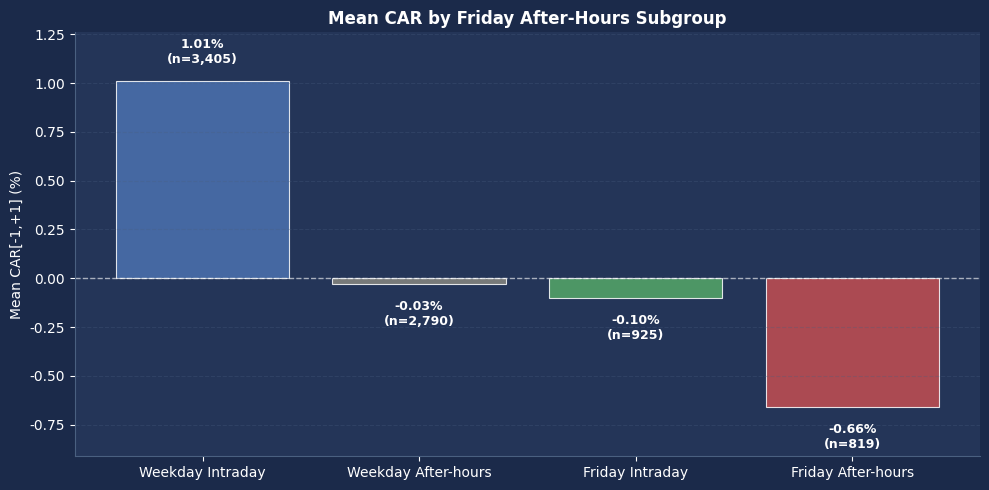

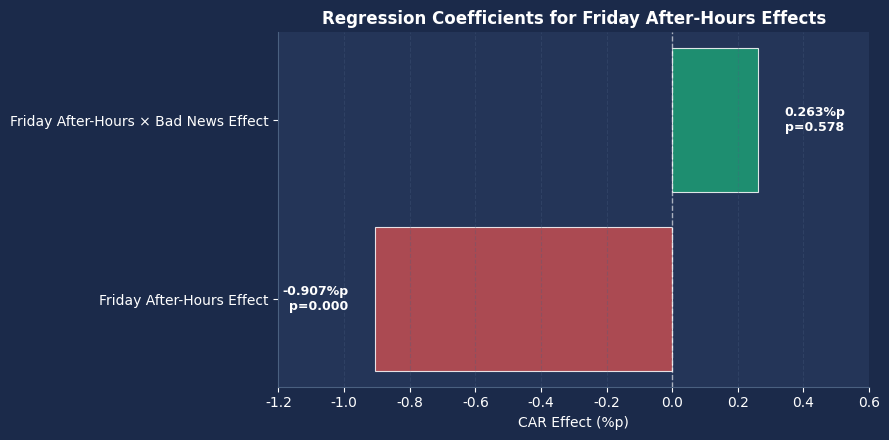


Files saved:
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\04_friday_after_group_car.png
C:\Users\c2066\OneDrive\바탕 화면\corporate_disclosure_timing\analysis\outputs\04_friday_after_regression_coef.png


In [5]:
# ============================================================
# 4. Friday After-Hours Subgroup Analysis
# - Friday after-hours disclosure = proxy for the weekend effect
# - Based on Market Model CAR[-1,+1]
# - Adjusted to prevent overlapping visualization labels
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf


# ------------------------------------------------------------
# 0. Settings and Data Loading
# ------------------------------------------------------------

OUTPUT_DIR = Path().resolve() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BG_COLOR = "#1B2A4A"
CAR_COL = "CAR_m1_p1"

reg_df = pd.read_csv(
    OUTPUT_DIR / "regression_analysis_dataset.csv"
)

print("Data loaded successfully")
print(f"Sample size: {len(reg_df):,}")


# ------------------------------------------------------------
# 1. Check Analysis Data
# ------------------------------------------------------------

need_cols = [
    "timing",
    "weekday",
    "after_dummy",
    "bad_dummy",
    "bad_severity",
    "is_kosdaq",
    "log_marcap",
    "fri_dummy",
    "p_after_hat",
    "roa",
    "debt_ratio",
    CAR_COL
]

missing = [
    c for c in need_cols
    if c not in reg_df.columns
]

if missing:
    raise ValueError(
        f"Required columns are missing from reg_df: {missing}"
    )

weekend_df = reg_df.copy()


# ------------------------------------------------------------
# 2. Create Friday After-Hours Dummy
# ------------------------------------------------------------

weekend_df["friday_after"] = (
    (weekend_df["weekday"] == 4)
    & (weekend_df["timing"] == "After-hours")
).astype(int)


# Friday After-Hours × Bad News
weekend_df["friday_after_bad"] = (
    weekend_df["friday_after"]
    * weekend_df["bad_dummy"]
)


# After-Hours × Bad News
weekend_df["after_bad"] = (
    weekend_df["after_dummy"]
    * weekend_df["bad_dummy"]
)


# Create timing groups
weekend_df["timing_group"] = np.select(
    [
        (
            (weekend_df["weekday"] == 4)
            & (weekend_df["timing"] == "After-hours")
        ),
        (
            (weekend_df["weekday"] == 4)
            & (weekend_df["timing"] == "Intraday")
        ),
        (
            (weekend_df["weekday"] != 4)
            & (weekend_df["timing"] == "After-hours")
        ),
        (
            (weekend_df["weekday"] != 4)
            & (weekend_df["timing"] == "Intraday")
        ),
    ],
    [
        "Friday After-hours",
        "Friday Intraday",
        "Weekday After-hours",
        "Weekday Intraday",
    ],
    default="Other"
)


# ------------------------------------------------------------
# 3. Descriptive Statistics
# ------------------------------------------------------------

sub_df = weekend_df[
    weekend_df["timing"].isin(
        ["Intraday", "After-hours"]
    )
].dropna(
    subset=[CAR_COL]
).copy()


print(
    "\n=== 4. Friday After-Hours Subgroup Analysis ==="
)

print(
    f"Total analysis sample: {len(sub_df):,}"
)

print(
    f"Friday after-hours disclosures: "
    f"{sub_df['friday_after'].sum():,}"
)

print(
    f"Friday after-hours share: "
    f"{sub_df['friday_after'].mean() * 100:.1f}%"
)


group_summary = (
    sub_df
    .groupby("timing_group")
    .agg(
        n=(CAR_COL, "size"),
        mean_car=(CAR_COL, "mean"),
        median_car=(CAR_COL, "median"),
        std_car=(CAR_COL, "std"),
        bad_ratio=("bad_dummy", "mean")
    )
    .reset_index()
)


group_summary["mean_car_pct"] = (
    group_summary["mean_car"] * 100
)

group_summary["median_car_pct"] = (
    group_summary["median_car"] * 100
)

group_summary["bad_ratio_pct"] = (
    group_summary["bad_ratio"] * 100
)


print(
    "\n=== CAR Descriptive Statistics by Group ==="
)

print(
    group_summary[
        [
            "timing_group",
            "n",
            "mean_car_pct",
            "median_car_pct",
            "std_car",
            "bad_ratio_pct"
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 4. Mean Difference Test:
# Friday After-Hours vs. Others
# ------------------------------------------------------------

fri_after_car = sub_df.loc[
    sub_df["friday_after"] == 1,
    CAR_COL
]

other_car = sub_df.loc[
    sub_df["friday_after"] == 0,
    CAR_COL
]


t_stat, p_val = stats.ttest_ind(
    fri_after_car,
    other_car,
    equal_var=False,
    nan_policy="omit"
)


print(
    "\n=== Mean Difference Test: "
    "Friday After-Hours vs. Others ==="
)

print(
    f"Mean CAR for Friday after-hours: "
    f"{fri_after_car.mean() * 100:.3f}%"
)

print(
    f"Mean CAR for others: "
    f"{other_car.mean() * 100:.3f}%"
)

print(
    f"Difference: "
    f"{(fri_after_car.mean() - other_car.mean()) * 100:.3f}%p"
)

print(
    f"t-stat: {t_stat:.3f}"
)

print(
    f"p-value: {p_val:.4f}"
)


# ------------------------------------------------------------
# 5. Bad-News Sample:
# Friday After-Hours vs. Others
# ------------------------------------------------------------

bad_sub = sub_df[
    sub_df["bad_dummy"] == 1
].copy()


bad_fri_after = bad_sub.loc[
    bad_sub["friday_after"] == 1,
    CAR_COL
]

bad_other = bad_sub.loc[
    bad_sub["friday_after"] == 0,
    CAR_COL
]


bad_t, bad_p = stats.ttest_ind(
    bad_fri_after,
    bad_other,
    equal_var=False,
    nan_policy="omit"
)


print(
    "\n=== Bad-News Sample: "
    "Friday After-Hours vs. Others ==="
)

print(
    f"Bad-news sample size: "
    f"{len(bad_sub):,}"
)

print(
    f"Friday after-hours observations "
    f"within bad-news sample: "
    f"{bad_sub['friday_after'].sum():,}"
)

print(
    f"Mean CAR for Friday after-hours bad news: "
    f"{bad_fri_after.mean() * 100:.3f}%"
)

print(
    f"Mean CAR for other bad news: "
    f"{bad_other.mean() * 100:.3f}%"
)

print(
    f"Difference: "
    f"{(bad_fri_after.mean() - bad_other.mean()) * 100:.3f}%p"
)

print(
    f"t-stat: {bad_t:.3f}"
)

print(
    f"p-value: {bad_p:.4f}"
)


# ------------------------------------------------------------
# 6. Regression Model 1:
# Effect of Friday After-Hours Disclosure
# ------------------------------------------------------------

reg_weekend1 = sub_df[
    [
        CAR_COL,
        "friday_after",
        "bad_dummy",
        "bad_severity",
        "is_kosdaq",
        "log_marcap",
        "p_after_hat",
        "roa",
        "debt_ratio",
    ]
].dropna().copy()


formula1 = (
    f"{CAR_COL} ~ friday_after + bad_dummy + bad_severity "
    "+ is_kosdaq + log_marcap + p_after_hat "
    "+ roa + debt_ratio"
)


model_weekend1 = smf.ols(
    formula1,
    data=reg_weekend1
).fit(
    cov_type="HC3"
)


print(
    "\n=== Regression Model 1: "
    "Effect of Friday After-Hours Disclosure ==="
)

print(
    model_weekend1.summary()
)


# ------------------------------------------------------------
# 7. Regression Model 2:
# Friday After-Hours × Bad News Effect
# ------------------------------------------------------------

reg_weekend2 = sub_df[
    [
        CAR_COL,
        "friday_after",
        "bad_dummy",
        "friday_after_bad",
        "bad_severity",
        "is_kosdaq",
        "log_marcap",
        "p_after_hat",
        "roa",
        "debt_ratio",
    ]
].dropna().copy()


formula2 = (
    f"{CAR_COL} ~ friday_after + bad_dummy "
    "+ friday_after_bad + bad_severity "
    "+ is_kosdaq + log_marcap "
    "+ p_after_hat + roa + debt_ratio"
)


model_weekend2 = smf.ols(
    formula2,
    data=reg_weekend2
).fit(
    cov_type="HC3"
)


print(
    "\n=== Regression Model 2: "
    "Friday After-Hours × Bad News Effect ==="
)

print(
    model_weekend2.summary()
)


# ------------------------------------------------------------
# 8. Summary of Key Results
# ------------------------------------------------------------

coef_summary = pd.DataFrame({
    "Model": [
        "Friday After-Hours Effect",
        "Friday After-Hours × Bad News Effect"
    ],
    "Variable": [
        "friday_after",
        "friday_after_bad"
    ],
    "Coefficient": [
        model_weekend1.params.get(
            "friday_after",
            np.nan
        ),
        model_weekend2.params.get(
            "friday_after_bad",
            np.nan
        ),
    ],
    "p-value": [
        model_weekend1.pvalues.get(
            "friday_after",
            np.nan
        ),
        model_weekend2.pvalues.get(
            "friday_after_bad",
            np.nan
        ),
    ]
})


coef_summary["Coefficient_pct"] = (
    coef_summary["Coefficient"] * 100
)

coef_summary["Coefficient"] = (
    coef_summary["Coefficient"].round(6)
)

coef_summary["Coefficient_pct"] = (
    coef_summary["Coefficient_pct"].round(3)
)

coef_summary["p-value"] = (
    coef_summary["p-value"].round(4)
)


print(
    "\n=== Summary of Key Results ==="
)

print(
    coef_summary.to_string(index=False)
)


# ------------------------------------------------------------
# 9. Visualization 1:
# Mean CAR by Timing Group
# ------------------------------------------------------------

plot_order = [
    "Weekday Intraday",
    "Weekday After-hours",
    "Friday Intraday",
    "Friday After-hours"
]


plot_df = (
    group_summary
    .set_index("timing_group")
    .reindex(plot_order)
    .reset_index()
    .dropna(subset=["mean_car_pct"])
)


fig, ax = plt.subplots(
    figsize=(10, 5)
)

fig.patch.set_facecolor(
    BG_COLOR
)

ax.set_facecolor(
    "#243558"
)


colors = [
    "#4C72B0",
    "#888780",
    "#55A868",
    "#C44E52"
][:len(plot_df)]


bars = ax.bar(
    plot_df["timing_group"],
    plot_df["mean_car_pct"],
    color=colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8
)


for bar, val, n in zip(
    bars,
    plot_df["mean_car_pct"],
    plot_df["n"]
):

    if val >= 0:
        y_pos = val + 0.08
        va = "bottom"

    else:
        y_pos = val - 0.08
        va = "top"

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        y_pos,
        f"{val:.2f}%\n(n={int(n):,})",
        ha="center",
        va=va,
        fontsize=9,
        fontweight="bold",
        color="white"
    )


ax.axhline(
    0,
    color="white",
    linestyle="--",
    linewidth=1,
    alpha=0.6
)


# Add y-axis margin to prevent label overlap
y_min = min(
    plot_df["mean_car_pct"].min() - 0.25,
    -0.8
)

y_max = max(
    plot_df["mean_car_pct"].max() + 0.25,
    1.2
)

ax.set_ylim(
    y_min,
    y_max
)


ax.set_ylabel(
    "Mean CAR[-1,+1] (%)"
)

ax.set_title(
    "Mean CAR by Friday After-Hours Subgroup",
    fontsize=12,
    fontweight="bold"
)


ax.spines[
    ["top", "right"]
].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color("#4A6080")


ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
    color="#4A6080"
)


plt.tight_layout()


plt.savefig(
    OUTPUT_DIR
    / "04_friday_after_group_car.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)


plt.show()


# ------------------------------------------------------------
# 10. Visualization 2:
# Key Regression Coefficients
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 4.5)
)

fig.patch.set_facecolor(
    BG_COLOR
)

ax.set_facecolor(
    "#243558"
)


coef_plot = (
    coef_summary.copy()
)


colors = [
    "#C44E52"
    if v < 0
    else "#1D9E75"
    for v in coef_plot[
        "Coefficient_pct"
    ]
]


bars = ax.barh(
    coef_plot["Model"],
    coef_plot["Coefficient_pct"],
    color=colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8
)


for bar, val, p in zip(
    bars,
    coef_plot["Coefficient_pct"],
    coef_plot["p-value"]
):

    if val >= 0:
        x_pos = val + 0.08
        ha = "left"

    else:
        x_pos = val - 0.08
        ha = "right"

    ax.text(
        x_pos,
        bar.get_y()
        + bar.get_height() / 2,
        f"{val:.3f}%p\np={p:.3f}",
        va="center",
        ha=ha,
        fontsize=9,
        fontweight="bold",
        color="white"
    )


ax.axvline(
    0,
    color="white",
    linestyle="--",
    linewidth=1,
    alpha=0.6
)


# Add x-axis margin to prevent label overlap
x_min = min(
    coef_plot["Coefficient_pct"].min() - 0.25,
    -1.2
)

x_max = max(
    coef_plot["Coefficient_pct"].max() + 0.25,
    0.6
)

ax.set_xlim(
    x_min,
    x_max
)


ax.set_xlabel(
    "CAR Effect (%p)"
)

ax.set_title(
    "Regression Coefficients for Friday After-Hours Effects",
    fontsize=12,
    fontweight="bold"
)


ax.spines[
    ["top", "right"]
].set_visible(False)

ax.spines[
    ["left", "bottom"]
].set_color("#4A6080")


ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3,
    color="#4A6080"
)


plt.tight_layout()


plt.savefig(
    OUTPUT_DIR
    / "04_friday_after_regression_coef.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR
)


plt.show()


# ------------------------------------------------------------
# Saved Files
# ------------------------------------------------------------

print(
    "\nFiles saved:"
)

print(
    OUTPUT_DIR
    / "04_friday_after_group_car.png"
)

print(
    OUTPUT_DIR
    / "04_friday_after_regression_coef.png"
)

# 4. Friday After-Hours Subgroup Analysis

## 4.1 Analysis Objective

Friday after-hours disclosures have a structure in which information is effectively incorporated into the market over the weekend, making them directly comparable to the "Friday After-Hours Disclosure" or "Weekend Effect" discussed in prior international studies.

In particular, Friday after-hours disclosures provide more than two days for information to be absorbed before the next trading day. Therefore, they may exhibit effects that differ from ordinary after-hours disclosures in terms of investor attention, the speed of information diffusion, and market reactions.

Accordingly, this section treats Friday after-hours disclosures as a separate subgroup and analyzes their CAR[-1,+1] reactions.

---

## 4.2 Descriptive Statistics of CAR by Group

The results show that, among the full sample of 7,939 disclosures, 819 were released after market hours on Fridays, accounting for approximately 10.3% of the total sample.

The mean CAR[-1,+1] for each group is as follows.

| Group | Mean CAR |
|---|---:|
| Weekday Intraday | +1.01% |
| Weekday After-hours | -0.03% |
| Friday Intraday | -0.10% |
| Friday After-hours | -0.66% |

In particular, Friday after-hours disclosures recorded the lowest mean CAR among all groups.

In addition, the proportion of bad-news disclosures in the Friday after-hours group was approximately 54.6%, which was relatively higher than in the other groups. This suggests that firms tend to concentrate negative information in Friday after-hours disclosures.

---

## 4.3 Mean Difference Test

A comparison between Friday after-hours disclosures and other disclosures shows that the mean CAR for Friday after-hours disclosures was -0.661%, whereas the mean CAR for other disclosures was +0.458%. The difference between the two groups was approximately -1.119 percentage points and was statistically significant.

```text
t-stat = -4.668
p < 0.001
```

Thus, Friday after-hours disclosures were associated with more negative market reactions on average.

Additionally, when the analysis was restricted to bad-news disclosures, the mean CAR for Friday after-hours bad-news disclosures was -1.863%, compared with -1.101% for other bad-news disclosures. The difference was approximately -0.762 percentage points and was statistically significant.

```text
t-stat = -2.507
p = 0.0125
```

This suggests that, even among bad-news disclosures, Friday after-hours disclosures may be associated with relatively more negative short-term market reactions.

---

## 4.4 Regression Analysis Results

The regression analysis separately tests the effect of Friday after-hours disclosure (`friday_after`) and the effect of Friday after-hours bad-news disclosure (`friday_after_bad`).

First, Friday after-hours disclosure itself has a statistically significant negative effect on CAR.

```text
friday_after = -0.0091
p < 0.001
```

This indicates that Friday after-hours disclosures are associated with an additional negative CAR effect of approximately -0.91 percentage points on average.

In contrast, the key interaction term, Friday After-Hours × Bad News (`friday_after_bad`), is not statistically significant.

```text
friday_after_bad = +0.0026
p = 0.578
```

In other words, although Friday after-hours disclosures themselves are associated with negative market reactions, there is no evidence that disclosing bad news after market hours on Friday generates an additional negative effect.

---

## 4.5 Overall Interpretation

The results show that firms tend to release a relatively higher proportion of bad-news disclosures after market hours on Fridays, and Friday after-hours disclosures exhibit the lowest average CAR.

However, the key interaction term is not statistically significant in the regression analysis. Therefore, the market does not appear to impose an additional penalty specifically because bad news is disclosed after market hours on Friday.

This suggests that investors may respond more strongly to the underlying information contained in the disclosure than to the disclosure timing itself.

Therefore, although firms may use Friday after-hours disclosure as a strategy to mitigate negative market reactions, the results provide no evidence that such a strategy actually produces an additional mitigating effect on market reactions.